Using our MVHumanNet dataloader, we can get our cropped images without much hassle.

In this case, we first test on the consistent human case with no random cropping.

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
# MVHN (from what we did with SEVA)
from dataloader import MVHumanNetDataset
from torch.utils.data import DataLoader

def expand_only_include(only_include):
    if isinstance(only_include, str): # in the format ex: "100001-102000,102020-104000"
        only_include = only_include.split(",")
        expanded_includes = []
        for subrange in only_include:
            start, end = [int(num) for num in subrange.split("-")]
            print(start, end)
            expanded_includes.extend([str(i).zfill(6) for i in range(start, end + 1)])
        return expanded_includes
    else:
        return only_include

dataset = MVHumanNetDataset(
    root_dir="/workspace/datasetvol/mvhuman_data/mv_captures",
    num_images=8,
    step_size=60,
    only_include=expand_only_include("104500-104700"),
    preload_path="/workspace/datasetvol/mvhuman_data/preload_paths/shards/",
    iclight_dataset_path="/workspace/datasetvol/mvhuman_data/relit_images",
    # infu_dataset_path="/workspace/datasetvol/mvhuman_data/inconsistent_images",
    arcface_embeddings_dir="/workspace/datasetvol/mvhuman_data/arcface_embeddings",
    use_sapiens_conditioning=["depth", "seg_masks"],
    random_crop=False,
    maximal_crop=True,
    crop_padding=60,
    use_inconsistent=True,
    random_crop_prob=1.0
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

/root/miniconda3/envs/NoPo-Avatar/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


104500 104700
Detected Arrow dataset at /workspace/datasetvol/mvhuman_data/preload_paths/shards/
Loading Arrow dataset...
Loaded Arrow dataset with 5080 subjects
Pre-loading camera parameters from Arrow dataset...


Indexing Arrow dataset: 100%|██████████| 5080/5080 [00:00<00:00, 7634.99it/s]


Loaded 561 scenes from Arrow dataset
MVHN::init done!


In [3]:
batch = next(iter(loader))

tensor([[False, False, False,  True, False, False, False, False]])
tensor([[False, False, False,  True, False, False, False, False]])
torch.Size([8, 3, 576, 576]) torch.Size([8, 1, 576, 576]) torch.Size([8, 1, 576, 576])


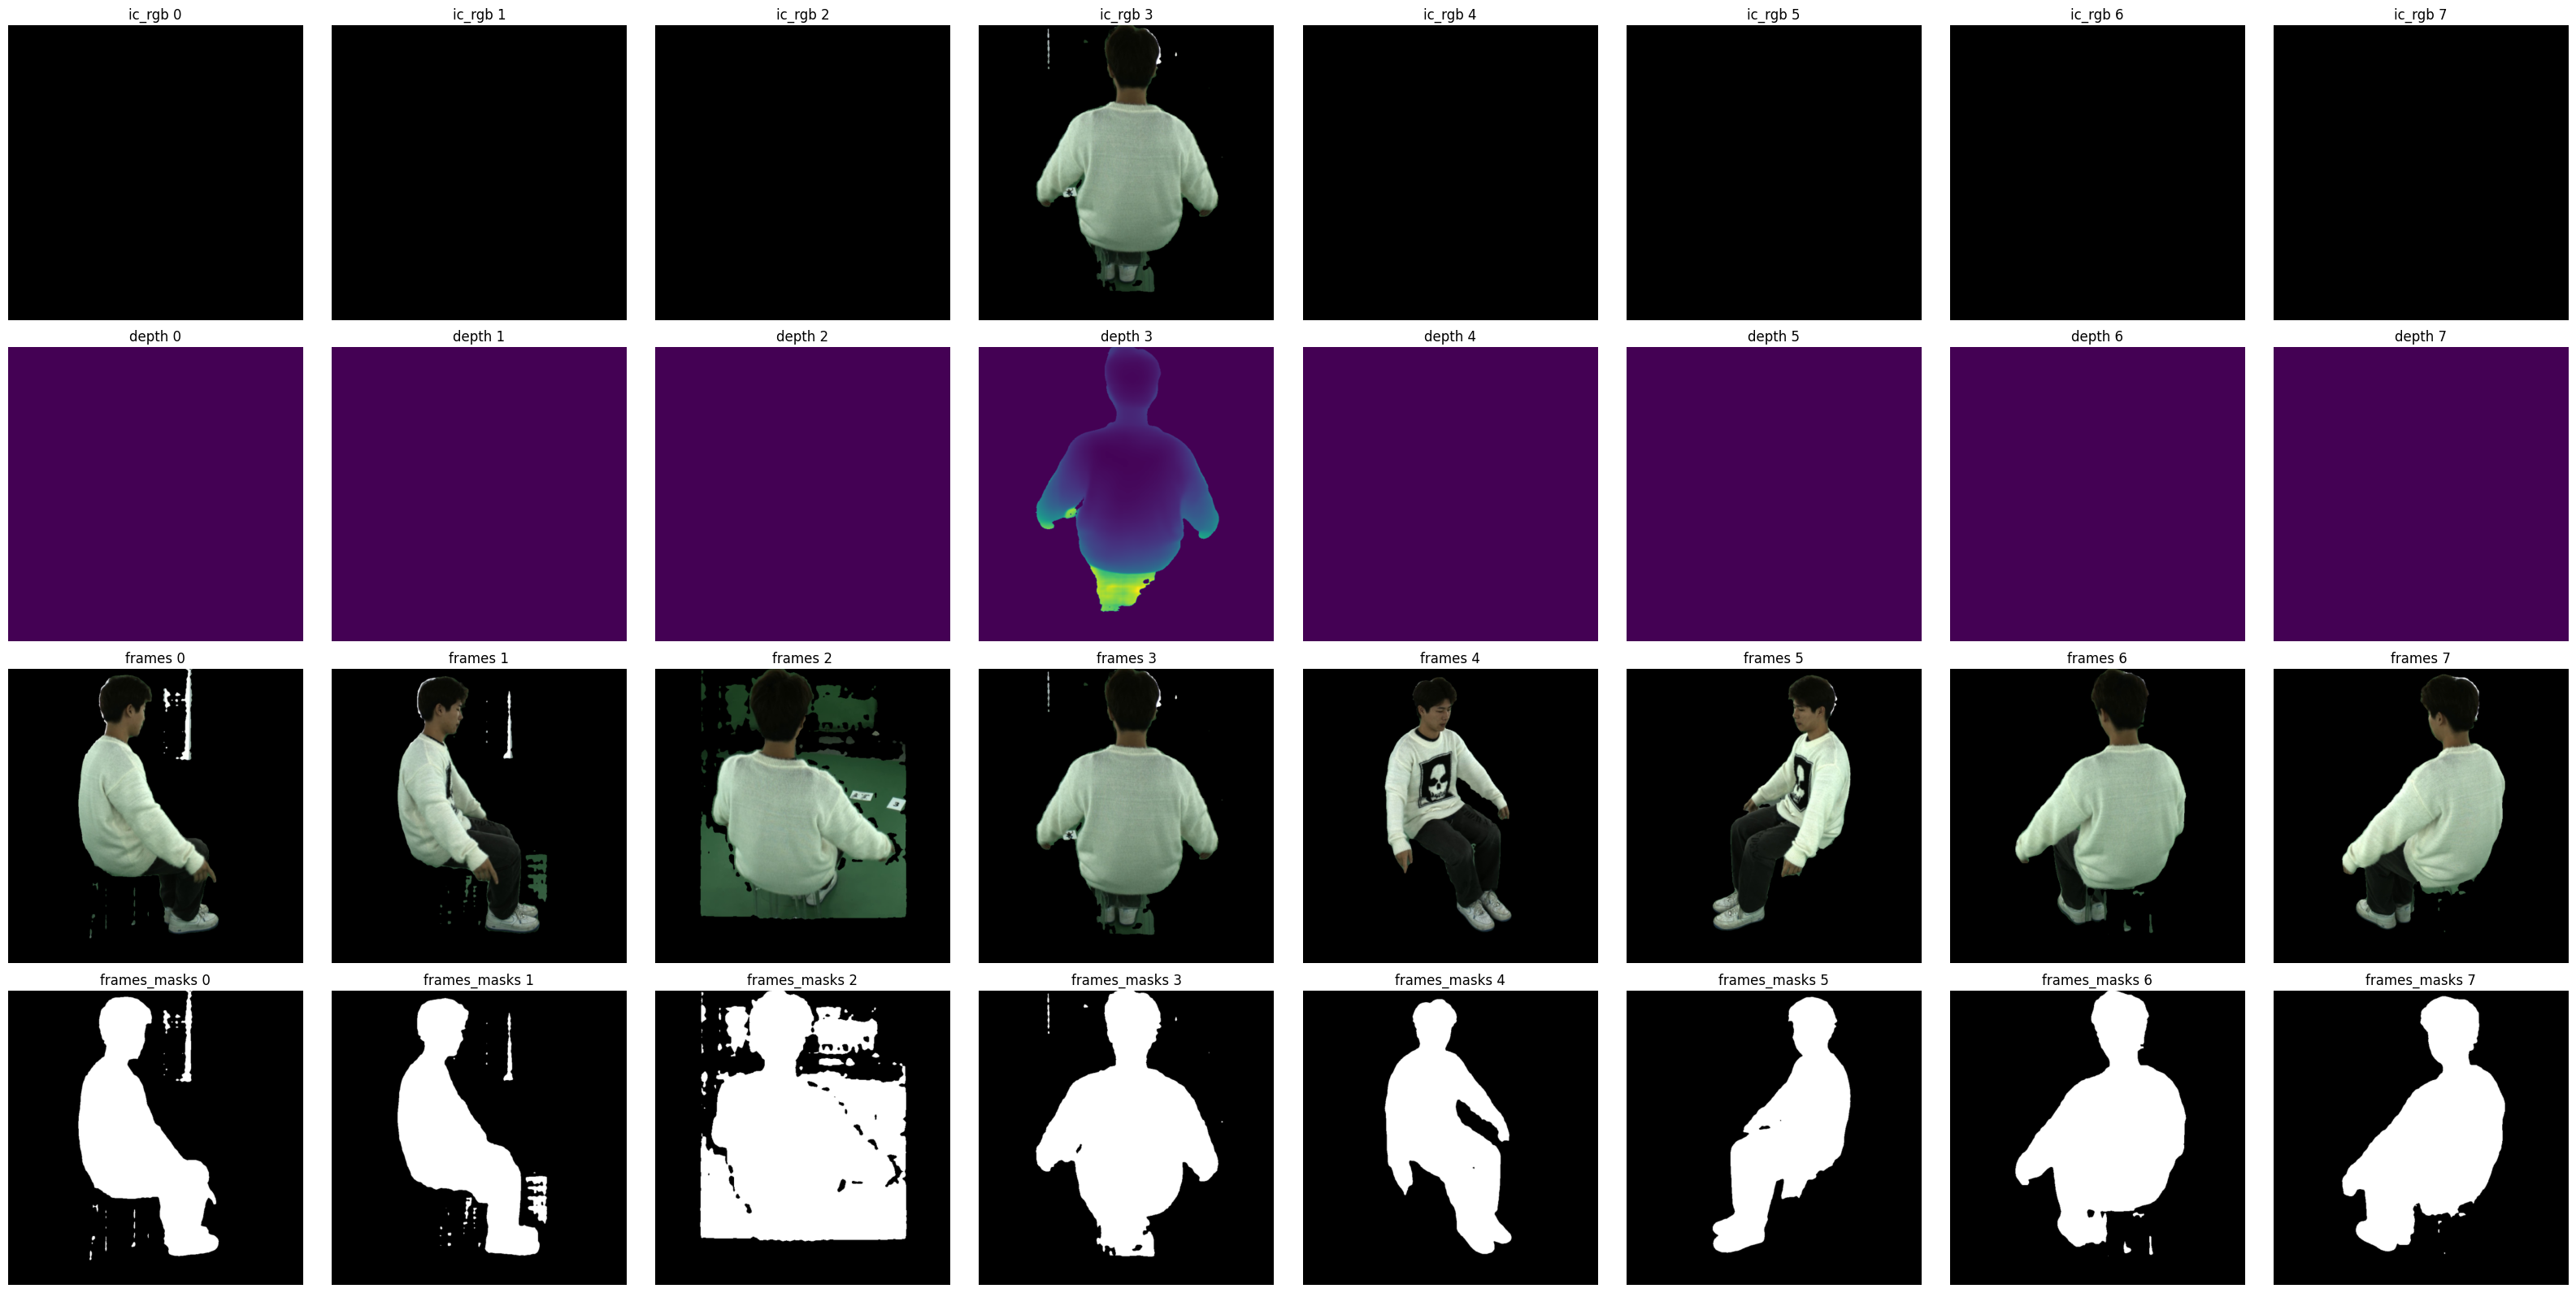

ic_rgb shape: torch.Size([1, 8, 3, 576, 576]), sapiens_conditioning[depth] shape: torch.Size([1, 8, 1, 576, 576]), frames shape: torch.Size([1, 8, 3, 576, 576]), frames_masks shape: torch.Size([1, 8, 1, 576, 576])


In [4]:
# visualize batch data
import matplotlib.pyplot as plt

print(batch['mask'])
print(batch['ref_mask'])

# Prepare images from "ic_rgb", "sapiens_conditioning" ("depth"), "frames", and "frames_masks"
ic_rgb_images = batch["ic_rgb"].squeeze(0).detach().cpu()  # (8, 3, H, W)
sapiens_depth_images = batch["sapiens_conditioning"]["depth"].squeeze(0).detach().cpu()  # (8, 3, H, W)
original_frames = batch["frames"].squeeze(0).detach().cpu()  # (8, 3, H, W)
frames_masks = batch["frames_masks"].squeeze(0).detach().cpu()  # (8, 3, H, W) or (8, 1, H, W); could be 1-chan masks

num_images = ic_rgb_images.shape[0]
print(ic_rgb_images.shape, sapiens_depth_images.shape, frames_masks.shape)
assert sapiens_depth_images.shape[0] == num_images, "Batch size mismatch"
assert frames_masks.shape[0] == num_images, "Frames masks batch size mismatch"

fig, axes = plt.subplots(4, num_images, figsize=(4*num_images, 16))

for i in range(num_images):
    # ic_rgb image
    if batch["ref_mask"][:, i]:
        img_rgb = batch["frames"][:, i, ...].detach().cpu().permute(0, 2, 3, 1).squeeze(0)
    else:
        img_rgb = ic_rgb_images[i].permute(1, 2, 0)

    img_rgb = img_rgb.float()
    img_rgb = img_rgb.clamp(-1, 1)
    img_rgb = (img_rgb + 1) * 0.5
    img_rgb = img_rgb.clamp(0, 1).numpy()
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f'ic_rgb {i}')
    axes[0, i].axis('off')
    
    # sapiens_conditioning depth image
    img_depth = sapiens_depth_images[i].float().permute(1, 2, 0)
    img_depth = img_depth.clamp(-1, 1)
    img_depth = (img_depth + 1) * 0.5
    img_depth = img_depth.clamp(0, 1).numpy()
    axes[1, i].imshow(img_depth)
    axes[1, i].set_title(f'depth {i}')
    axes[1, i].axis('off')

    # original frames image
    img_frame = original_frames[i].float().permute(1, 2, 0)
    img_frame = img_frame.clamp(-1, 1)
    img_frame = (img_frame + 1) * 0.5
    img_frame = img_frame.clamp(0, 1).numpy()
    axes[2, i].imshow(img_frame)
    axes[2, i].set_title(f'frames {i}')
    axes[2, i].axis('off')

    # frames_masks image
    img_mask = frames_masks[i]
    # If mask is (1, H, W) take channel 0, else assume (3, H, W)
    if img_mask.shape[0] == 1:
        img_mask = img_mask[0]
    elif img_mask.shape[0] == 3:
        img_mask = img_mask.permute(1, 2, 0)
        img_mask = img_mask.float().clamp(0, 1).numpy()
        # Visualize as RGB mask image
        axes[3, i].imshow(img_mask)
    else:
        # Unexpected shape, visualize first channel
        img_mask = img_mask[0]
        axes[3, i].imshow(img_mask.float().clamp(0, 1).numpy(), cmap="gray")
        axes[3, i].set_title(f'frames_masks {i} (unexpected shape)')
        axes[3, i].axis('off')
        continue

    if len(img_mask.shape) == 2:  # single channel mask
        img_mask = img_mask.float().clamp(0, 1).numpy()
        axes[3, i].imshow(img_mask, cmap="gray")
    else:  # RGB mask
        axes[3, i].imshow(img_mask)
    axes[3, i].set_title(f'frames_masks {i}')
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

print(f"ic_rgb shape: {batch['ic_rgb'].shape}, sapiens_conditioning[depth] shape: {batch['sapiens_conditioning']['depth'].shape}, frames shape: {batch['frames'].shape}, frames_masks shape: {batch['frames_masks'].shape}")

In [5]:
# CREATE an INPUT DIRECTORY for inference script
import os
from PIL import Image
import numpy as np

subject_id = batch["subject_id"][0]
timestep = batch["timestep"][0]
num_images = batch["frames"].shape[1]

input_dir = f"/workspace/NoPo-Avatar/subject_{subject_id}_{timestep}"
test_dir = f"/workspace/NoPo-Avatar/subject_{subject_id}_{timestep}/test"
os.makedirs(input_dir, exist_ok=True)
os.makedirs(os.path.join(input_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(input_dir, "masks"), exist_ok=True)

# make a test dir for the NON-input views (change later to full 48 views?)
# in this case, we need to include extrinsics as well (c2w OpenCV coordinate system)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(os.path.join(test_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(test_dir, "masks"), exist_ok=True)

num_input_frames = 3
frames_to_choose = np.random.choice(num_images, size=num_input_frames, replace=False)
frames_to_choose = np.array([1,2,4]) # manual selection
test_frames_mask = np.ones(num_images, dtype=bool)
test_frames_mask[frames_to_choose] = False

inconsistent_to_use = [0,0,0] # 0 for consistent (MVHN raw), 1 for inconsistent
resize_to = 1024
intrinsics = batch["K"].squeeze(0).numpy() # should be normalized! (8,3,3)
extrinsics = batch["c2w"].squeeze(0).numpy() # should be OpenCV c2w! (8,4,4)

assert num_input_frames == len(frames_to_choose) == len(inconsistent_to_use)

def scale_intrinsics(intrinsics, resize_to, orig_shape):
    K = intrinsics.copy()
    K[0,0] *= (resize_to / orig_shape[0])
    K[1,1] *= (resize_to / orig_shape[1])
    K[0,2] *= (resize_to / orig_shape[0])
    K[1,2] *= (resize_to / orig_shape[1])
    return K

input_K = []
test_K = []

# copy the images to the input directory
for i in range(num_images):
    is_input = i in frames_to_choose
    save_path = input_dir if is_input else test_dir
    img_rgb = batch["frames"][:, i, ...].detach().cpu().permute(0, 2, 3, 1).squeeze(0)  # (H, W, 3)

    if is_input:
        # trigger if we should replace with IC image
        use_inconsistent = inconsistent_to_use.pop(0)
        if use_inconsistent: # '1'
            img_rgb = batch["ic_rgb"][:, i, ...].detach().cpu().permute(0, 2, 3, 1).squeeze(0)  # (H, W, 3)

    orig_shape = img_rgb.shape[:2]
    # de-normalize
    img_rgb = img_rgb.clamp(-1, 1)
    img_rgb = (img_rgb + 1) * 0.5
    img_rgb = img_rgb.clamp(0, 1).numpy()
    # img_rgb is now (H, W, 3) and float32, convert to uint8 for PIL
    img_rgb = (img_rgb * 255).round().astype('uint8')
    img_rgb = Image.fromarray(img_rgb)
    # Resize using PIL Image.resize() method
    img_rgb = img_rgb.resize((resize_to, resize_to), Image.Resampling.LANCZOS)
    img_rgb.save(os.path.join(save_path, "images", f"{i}.png"))

    # save mask to 'masks'
    img_mask = batch["frames_masks"][:, i, ...].detach().cpu().squeeze(0)  # (1, H, W) or (H, W)
    # Handle single channel mask - squeeze channel dimension if present
    if len(img_mask.shape) == 3 and img_mask.shape[0] == 1:
        img_mask = img_mask.squeeze(0)  # (H, W) for grayscale
    elif len(img_mask.shape) == 3 and img_mask.shape[0] == 3:
        img_mask = img_mask.permute(1, 2, 0)  # (H, W, 3) for RGB
    # img_mask is now (H, W) for grayscale or (H, W, 3) for RGB
    img_mask = img_mask.clamp(0, 1).numpy()
    img_mask = (img_mask * 255).round().astype('uint8')
    # Use 'L' mode for grayscale (single channel), 'RGB' for 3 channels
    mode = 'L' if len(img_mask.shape) == 2 else 'RGB'
    img_mask = Image.fromarray(img_mask, mode=mode)
    # Resize using PIL Image.resize() method (use NEAREST for masks to preserve binary values)
    img_mask = img_mask.resize((resize_to, resize_to), Image.Resampling.NEAREST)
    img_mask.save(os.path.join(save_path, "masks", f"{i}.png"))
    if is_input:
        K = scale_intrinsics(intrinsics[i], resize_to, orig_shape)
        input_K.append(K)
    else: # test
        K = scale_intrinsics(intrinsics[i], resize_to, orig_shape)
        test_K.append(K)

# save intrinsic
input_K = np.stack(input_K)
test_K = np.stack(test_K)
np.save(os.path.join(input_dir, "intrinsics.npy"), input_K)
np.save(os.path.join(test_dir, "intrinsics.npy"), test_K)
np.save(os.path.join(input_dir, "extrinsics.npy"), extrinsics[~test_frames_mask])
np.save(os.path.join(test_dir, "extrinsics.npy"), extrinsics[test_frames_mask])

print(f"Input directory created at {input_dir}")

Input directory created at /workspace/NoPo-Avatar/subject_104541_1205


In [6]:
# call the inference script
!python inference.py --input {input_dir} --output {input_dir}_output --render

Using device: cuda
Setting render_no_canonical=True to bypass LBS warping (No-Pose mode).
/workspace/NoPo-Avatar/inference.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature

In [7]:
# visualize the output
!python visualize_gaussians.py --input {input_dir}_output/gaussians.npz --output {input_dir}_output

Loading /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians.npz...
Loaded 1,671,719 Gaussians

Gaussian Statistics
Number of Gaussians: 1,671,719

Positions (means):
  Range X: [-0.890, 0.868]
  Range Y: [-1.396, 0.465]
  Range Z: [-0.186, 0.185]

Opacities:
  Mean: 0.210
  Std: 0.255
  Range: [0.000, 1.000]
  Visible (>0.5): 238,381 (14.3%)

Scales:
  Mean: 0.0014
  Std: 0.0021
  Range: [0.0003, 0.0431]

Converting covariances to quaternions and scales...
Converting harmonics to RGB...
Saving 1671719 Gaussians to /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians.ply...
/workspace/NoPo-Avatar/visualize_gaussians.py:241: RuntimeWarning: divide by zero encountered in log
  opacity_logit = np.log(opacities[i] / (1 - opacities[i] + 1e-7))
✓ Saved PLY to /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians.ply
Creating 3D visualization...
✓ Saved plot to /workspace/NoPo-Avatar/subject_104541_1205_output/gaussians_3d.png
Figure(1200x1000)

Visualization Complete!

To

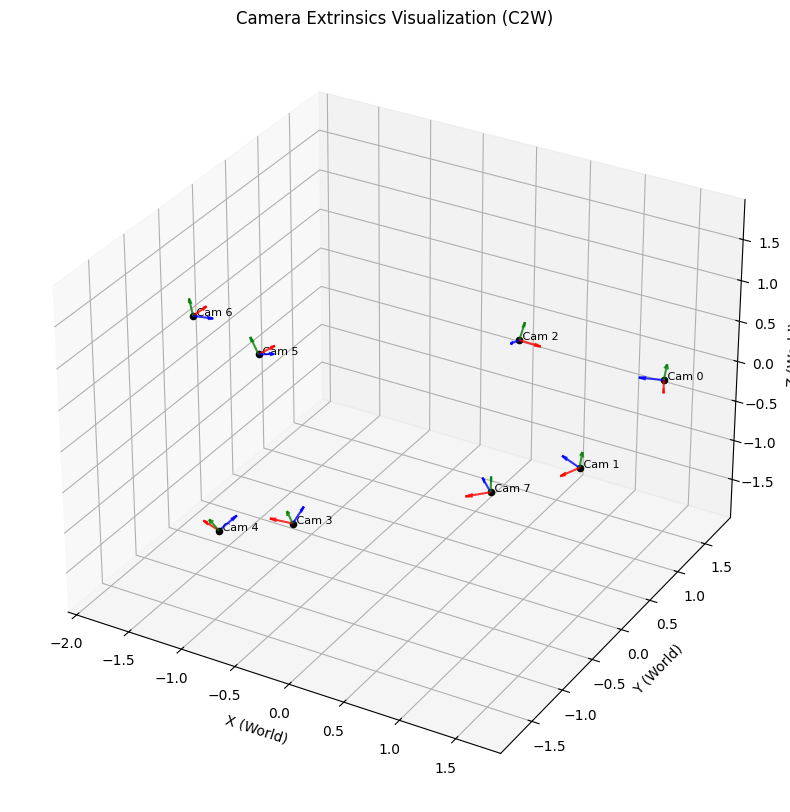

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from scipy.spatial.transform import Rotation as R

# ==========================================
# 1. SETTINGS & TRANSFORMATION MATRIX
# ==========================================
input_dir = "subject_104544_0305"  # Path to your data

# UPDATE THIS MATRIX TO TRANSFORM THE WHOLE SCENE
# Initially identity. Re-run cell after modifying this.
GLOBAL_TRANSFORM = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
])

# Example: Rotate 90 deg around X if the person is lying flat
# rot = R.from_euler('x', 90, degrees=True).as_matrix()
# GLOBAL_TRANSFORM[:3, :3] = rot

# ==========================================
# 2. LOAD DATA
# ==========================================
extr_path = Path(input_dir) / "extrinsics.npy"
extr_target_path = Path(input_dir) / "test" / "extrinsics.npy"
extrinsics = np.load(extr_path) # Expected shape [N, 4, 4]
extrinsics_target = np.load(extr_target_path) # Expected shape [N, 4, 4]
extrinsics = np.concatenate([extrinsics, extrinsics_target], axis=0)

# ==========================================
# 3. MATPLOTLIB VISUALIZATION
# ==========================================
def visualize_cameras_mpl(poses, transform, axis_length=0.2):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Apply global transform to all poses
    # effective_pose = GLOBAL_TRANSFORM @ pose
    transformed_poses = np.matmul(transform, poses)

    for i, pose in enumerate(transformed_poses):
        pos = pose[:3, 3]
        rot = pose[:3, :3] # Columns are local X, Y, Z in world space

        # Camera Center
        ax.scatter(pos[0], pos[1], pos[2], color='black', s=20)
        ax.text(pos[0], pos[1], pos[2], f" Cam {i}", fontsize=8)

        # Draw RGB Axes (R=X, G=Y, B=Z)
        # X-axis (Right)
        ax.quiver(pos[0], pos[1], pos[2], rot[0, 0], rot[1, 0], rot[2, 0], 
                  length=axis_length, color='red', alpha=0.8)
        # Y-axis (Down in OpenCV)
        ax.quiver(pos[0], pos[1], pos[2], rot[0, 1], rot[1, 1], rot[2, 1], 
                  length=axis_length, color='green', alpha=0.8)
        # Z-axis (Forward in OpenCV)
        ax.quiver(pos[0], pos[1], pos[2], rot[0, 2], rot[1, 2], rot[2, 2], 
                  length=axis_length, color='blue', alpha=0.8)

    # Set labels and equal aspect ratio
    ax.set_xlabel('X (World)')
    ax.set_ylabel('Y (World)')
    ax.set_zlabel('Z (World)')
    ax.set_title('Camera Extrinsics Visualization (C2W)')

    # Improve 3D perspective
    # Determine bounds for equal aspect ratio
    all_pos = transformed_poses[:, :3, 3]
    max_range = np.array([all_pos[:,0].max()-all_pos[:,0].min(), 
                          all_pos[:,1].max()-all_pos[:,1].min(), 
                          all_pos[:,2].max()-all_pos[:,2].min()]).max() / 2.0

    mid_x = (all_pos[:,0].max()+all_pos[:,0].min()) * 0.5
    mid_y = (all_pos[:,1].max()+all_pos[:,1].min()) * 0.5
    mid_z = (all_pos[:,2].max()+all_pos[:,2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()

# Execute
visualize_cameras_mpl(extrinsics, GLOBAL_TRANSFORM)